## Demand Estimation and Market Analysis: Air Fryers

### Dishitha Dhakshin (qxk8wp), Emerson Brown (gsz5cv)

## 3. Strategy: Costs, Markups, and Profit

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

In [57]:
df = pd.read_csv('air_fryers_clean_brand_year.csv')
df.head()

,category,year,brand,purchase_count,product_count,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,market_purchases,brand_share,log_brand_share
0,air_fryers,2019,chefman,1146,10,72.963695,4.434119,1.000000,0.0,0.780977,0.243455,0.184119,15076,0.076015,-2.576826
1,air_fryers,2019,cosori,11,2,159.990000,4.581818,1.000000,0.0,0.090909,0.090909,0.000000,15076,0.000730,-7.222964
2,air_fryers,2019,cuisinart,1616,22,229.465274,4.481312,0.993812,0.0,0.889851,0.000000,0.000000,15076,0.107190,-2.233150
3,air_fryers,2019,dash,3011,19,55.176333,4.390767,1.000000,0.0,0.973431,0.000000,0.000000,15076,0.199721,-1.610832
4,air_fryers,2019,gowise usa,4405,45,83.575551,4.552259,0.999773,0.0,0.129398,0.128490,0.000000,15076,0.292186,-1.230364


In [58]:
feature_cols = [
    'compact_share', 'dual_basket_share', 'oven_style_share',
    'rotisserie_share', 'window_share'
]

y = df['log_brand_share']

brand_dummies = pd.get_dummies(df['brand'],
                               prefix='brand', drop_first=True, dtype=int)
year_dummies = pd.get_dummies(df['year'].astype(str),
                              prefix='year', drop_first=True, dtype=int)

X = pd.concat(
    [df[['avg_price', 'avg_rating'] + feature_cols],
     brand_dummies,
     year_dummies],
    axis=1
)

model = LinearRegression()
model.fit(X, y)

predicted_log_share = model.predict(X)
r2 = r2_score(y, predicted_log_share)

coef_table = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_
})

price_coef = coef_table.loc[coef_table['feature'] == 'avg_price', 'coefficient'].iloc[0]
print('Estimated price coefficient:', price_coef)

Estimated price coefficient: -0.03766765298429369


In [59]:
# Compute

df['demand_slope'] = price_coef * df['brand_share'] * (1 - df['brand_share'])

df['unit_cost'] = df['avg_price'] + ( df['brand_share'] / df['demand_slope'] )

df['markup'] = df['avg_price'] - df['unit_cost']

df['average_profit'] = df['brand_share'] * df['markup']

df.head()

,category,year,brand,purchase_count,product_count,avg_price,avg_rating,compact_share,dual_basket_share,oven_style_share,rotisserie_share,window_share,market_purchases,brand_share,log_brand_share,demand_slope,unit_cost,markup,average_profit
0,air_fryers,2019,chefman,1146,10,72.963695,4.434119,1.000000,0.0,0.780977,0.243455,0.184119,15076,0.076015,-2.576826,-0.002646,44.231656,28.732039,2.184062
1,air_fryers,2019,cosori,11,2,159.990000,4.581818,1.000000,0.0,0.090909,0.090909,0.000000,15076,0.000730,-7.222964,-0.000027,133.422638,26.567362,0.019385
2,air_fryers,2019,cuisinart,1616,22,229.465274,4.481312,0.993812,0.0,0.889851,0.000000,0.000000,15076,0.107190,-2.233150,-0.003605,199.729962,29.735313,3.187335
3,air_fryers,2019,dash,3011,19,55.176333,4.390767,1.000000,0.0,0.973431,0.000000,0.000000,15076,0.199721,-1.610832,-0.006021,22.002913,33.173420,6.625442
4,air_fryers,2019,gowise usa,4405,45,83.575551,4.552259,0.999773,0.0,0.129398,0.128490,0.000000,15076,0.292186,-1.230364,-0.007790,46.068541,37.507010,10.959033


In [60]:
df[['unit_cost', 'markup']].describe()

,unit_cost,markup
count,50.000000,50.000000
mean,93.102239,29.703894
std,51.696080,2.615822
min,22.002913,26.567362
25%,53.159061,27.952365
50%,70.038270,28.813285
75%,123.561937,30.956852
max,199.729962,37.507010


The typical units costs are 93.10 across brands and the markups were about 29.70. 

In [61]:
(df['unit_cost'] < 0).sum()

np.int64(0)

None of the inferred unit costs were negative.

In [62]:
df.groupby('brand')['unit_cost'].mean().sort_values(ascending = False)

brand
cuisinart      194.896119
oster          161.804969
ninja          112.488470
nuwave         109.053549
cosori          86.283321
instant_pot     71.903119
chefman         61.569466
gowise usa      56.301040
ultrean         48.785765
dash            27.936578
Name: unit_cost, dtype: float64

Cuisinart has the highest average unit costs, followed by Oster, then Ninja. Dash has the lowest by a decent margin, with Ultrean just above.

In [63]:
df.groupby('brand')['markup'].mean().sort_values(ascending=False)

brand
ninja          32.854071
instant_pot    32.558234
gowise usa     31.153741
dash           29.542349
chefman        29.368946
ultrean        29.328841
cuisinart      29.050974
cosori         27.984628
nuwave         27.970835
oster          27.226315
Name: markup, dtype: float64

Ninja has the highest average markups, closely followed by Instant Pot. Oster, Nuwave, and Cosori all are close with the lowest markups.  

In [64]:
df.groupby('brand')['average_profit'].mean().sort_values(ascending = False)

brand
ninja          6.306093
instant_pot    6.010256
gowise usa     4.605764
dash           2.994372
chefman        2.820968
ultrean        2.780864
cuisinart      2.502997
cosori         1.436651
nuwave         1.422858
oster          0.678338
Name: average_profit, dtype: float64

Ninja seems to have the highest share-weighted average profit, closely followed by Instant Pot. Oster has the least by a significant amount.

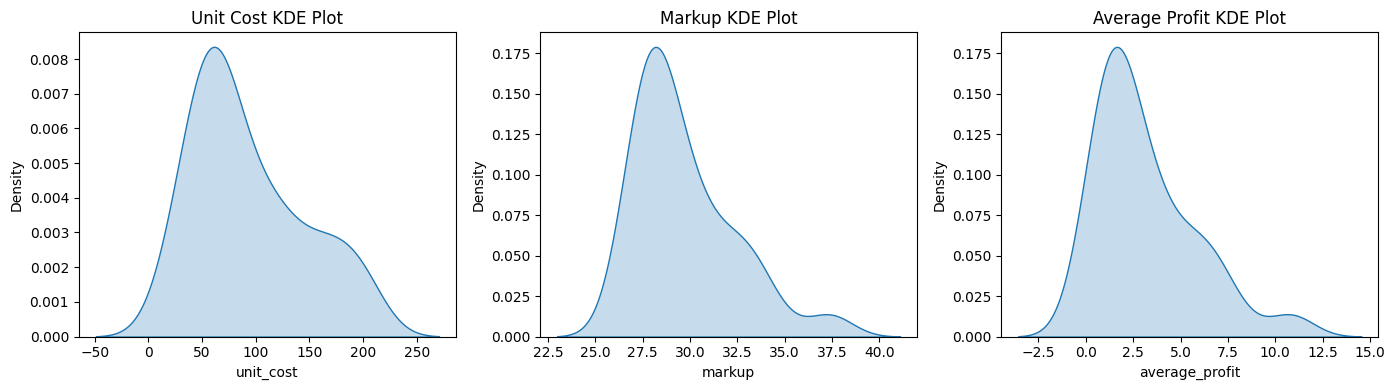

In [65]:
fig, axes = plt.subplots(1, 3, figsize=(14,4))
sns.kdeplot(df['unit_cost'], ax=axes[0], fill = True)
axes[0].set_title('Unit Cost KDE Plot')
sns.kdeplot(df['markup'], ax = axes[1], fill = True)
axes[1].set_title('Markup KDE Plot')
sns.kdeplot(df['average_profit'], ax = axes[2], fill = True)
axes[2].set_title('Average Profit KDE Plot')
plt.tight_layout()
plt.show()

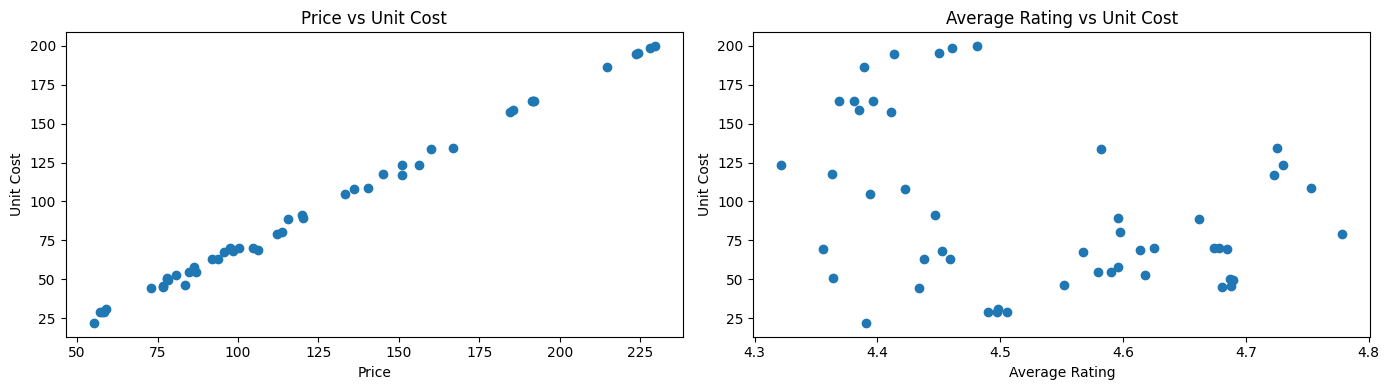

In [66]:
fig, axes = plt.subplots(1, 2, figsize = (14,4))
axes[0].scatter(df['avg_price'], df['unit_cost'])
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Unit Cost')
axes[0].set_title('Price vs Unit Cost')
axes[1].scatter(df['avg_rating'], df['unit_cost'])
axes[1].set_xlabel('Average Rating')
axes[1].set_ylabel('Unit Cost')
axes[1].set_title('Average Rating vs Unit Cost')
plt.tight_layout()
plt.show()


In [67]:
df['demand_slope'] * df['markup'] + df['brand_share']

0     0.000000e+00
1    -3.252607e-19
2    -2.775558e-17
3     0.000000e+00
4     0.000000e+00
5     0.000000e+00
6    -5.551115e-17
7    -6.938894e-18
8     0.000000e+00
9     6.938894e-18
10    0.000000e+00
11    1.734723e-18
12    2.775558e-17
13    0.000000e+00
14    2.775558e-17
15    2.775558e-17
16    5.551115e-17
17   -1.387779e-17
18   -1.734723e-18
19    0.000000e+00
20    0.000000e+00
21   -6.938894e-18
22    4.163336e-17
23    0.000000e+00
24   -1.387779e-17
25    2.775558e-17
26    2.775558e-17
27    1.387779e-17
28    3.469447e-18
29    0.000000e+00
30    1.387779e-17
31    0.000000e+00
32   -2.775558e-17
33    0.000000e+00
34    6.938894e-18
35   -5.551115e-17
36    0.000000e+00
37    6.938894e-18
38   -1.040834e-17
39    1.387779e-17
40    0.000000e+00
41    2.775558e-17
42   -2.775558e-17
43    0.000000e+00
44   -6.938894e-18
45   -2.775558e-17
46    5.551115e-17
47    6.938894e-18
48   -3.469447e-18
49    0.000000e+00
dtype: float64